# COE Final Project Part 3:
**Name:** Jana Daouk
**EID:** jd55586
**Course:** COE 311K

---

## Section 1: Review of Part 2

In Part 2, I used Backward Euler to solve a stiff scalar ODE. The main issue with Forward Euler is that it can become unstable for stiff problems, especially when the step size is too large. Backward Euler is more stable because it uses the future value \( y_{n+1} \), but that also means we have to solve an implicit equation at every step.

For my ODE, I used:

$$
\frac{dy}{dt} = y^2 - 10
$$

The Backward Euler update equation is:

$$
y_{n+1} = y_n + h f(t_{n+1}, y_{n+1})
$$

Since \( y_{n+1} \) appears on both sides, this equation is implicit and cannot be solved directly. Because the ODE is nonlinear, I used Newton-Raphson to solve for \( y_{n+1} \) at each time step.

To apply Newton-Raphson, I rewrote the equation as a root-finding problem:

$$
g(y_{n+1}) = y_{n+1} - y_n - h f(t_{n+1}, y_{n+1})
$$

and then iteratively solved for the root.

The stiffness of this problem comes from how sensitive the system is to changes in \( y \). The stiffness parameter can be approximated using the derivative of the function:

$$
\lambda = \frac{\partial f}{\partial y} = 2y
$$

This value can become large depending on \( y \), which makes explicit methods like Forward Euler unstable unless a very small step size is used. Backward Euler is better suited for this type of problem because it remains stable even for larger step sizes.

In Part 3, I improve this solver by adding Newton-Raphson damping to make the iterations more robust, and adaptive step sizes to automatically adjust \( h \) for better accuracy and efficiency.

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# same ODE from Part 2
def f(t, y):
    return y**2 - 10

# derivative wrt y (needed for Newton-Raphson)
def dfdy(t, y):
    return 2 * y

## Section 2: Newton-Raphson Damping Implementation

Basic Newton-Raphson can fail when the Newton step is too large. This can happen if the first guess is bad, the step size is too large, or the function is very nonlinear. Damping fixes this by not always taking the full Newton step.

Instead of using:

$$
y^{k+1} = y^k - \frac{g(y^k)}{g'(y^k)}
$$

we use:

$$
y^{k+1} = y^k - \alpha \frac{g(y^k)}{g'(y^k)}
$$

where $0 < \alpha \leq 1$. If $\alpha = 1$, this is regular Newton-Raphson. If the residual does not improve, we cut $\alpha$ in half and try again.

In [64]:
def basic_newton_raphson(y_n, t_next, h, max_iter=50, tol=1e-10):
    """
    Basic Newton-Raphson solver for one Backward Euler step.

    It solves:
        g(y_next) = y_next - y_n - h*f(t_next, y_next) = 0
    """

    y_guess = y_n

    for k in range(max_iter):
        # residual for Backward Euler
        g = y_guess - y_n - h * f(t_next, y_guess)

        # derivative of residual
        g_prime = 1 - h * dfdy(t_next, y_guess)

        # avoid dividing by something basically zero
        if abs(g_prime) < 1e-14:
            return y_guess, k + 1, False

        # normal Newton step
        y_new = y_guess - g / g_prime

        # check convergence
        if abs(y_new - y_guess) < tol:
            return y_new, k + 1, True

        y_guess = y_new

    return y_guess, max_iter, False

In [65]:
def damped_newton_raphson(
    y_n,
    t_next,
    h,
    max_iter=50,
    tol=1e-10,
    alpha_min=1e-4
):
    """
    Damped Newton-Raphson solver with line search.

    This is the upgraded version of Newton-Raphson.
    If the full Newton step makes the residual worse, we cut alpha in half.

    Returns:
        y_guess: solution for y_{n+1}
        iterations: number of Newton iterations used
        success: whether it converged
        damping_used: whether alpha ever had to be smaller than 1
        backtracking_steps: total number of alpha reductions
        final_alpha: final damping factor used
    """

    y_guess = y_n
    damping_used = False
    backtracking_steps = 0
    final_alpha = 1.0

    for k in range(max_iter):
        g = y_guess - y_n - h * f(t_next, y_guess)
        g_prime = 1 - h * dfdy(t_next, y_guess)

        if abs(g) < tol:
            return y_guess, k + 1, True, damping_used, backtracking_steps, final_alpha

        if abs(g_prime) < 1e-14:
            return y_guess, k + 1, False, damping_used, backtracking_steps, final_alpha

        # full Newton step first
        delta = -g / g_prime
        alpha = 1.0
        current_residual = abs(g)

        # line search: only accept the step if residual gets smaller
        while alpha >= alpha_min:
            y_new = y_guess + alpha * delta
            g_new = y_new - y_n - h * f(t_next, y_new)

            if abs(g_new) < current_residual:
                break

            # if it got worse, take a smaller step
            alpha = alpha / 2
            backtracking_steps += 1
            damping_used = True

        final_alpha = alpha

        # if alpha got too small, just stop because it is not making progress
        if alpha < alpha_min:
            return y_guess, k + 1, False, damping_used, backtracking_steps, final_alpha

        if abs(y_new - y_guess) < tol:
            return y_new, k + 1, True, damping_used, backtracking_steps, final_alpha

        y_guess = y_new

    return y_guess, max_iter, False, damping_used, backtracking_steps, final_alpha

In [66]:
def backward_euler_fixed(y0, t0, t_final, h, solver="damped"):
    """
    Fixed-step Backward Euler method.

    This is used as the baseline comparison for the adaptive method.
    """

    t_values = [t0]
    y_values = [y0]

    stats = {
        "steps": 0,
        "newton_iterations": 0,
        "function_evals": 0,
        "damping_used_count": 0,
        "backtracking_steps": 0,
        "failed_steps": 0
    }

    t = t0
    y = y0

    while t < t_final:
        # make sure we land exactly on t_final
        h_step = min(h, t_final - t)
        t_next = t + h_step

        if solver == "basic":
            y_next, iters, success = basic_newton_raphson(y, t_next, h_step)
            damping_used = False
            backtracks = 0
        else:
            y_next, iters, success, damping_used, backtracks, final_alpha = damped_newton_raphson(y, t_next, h_step)

        if not success:
            stats["failed_steps"] += 1
            break

        t_values.append(t_next)
        y_values.append(y_next)

        stats["steps"] += 1
        stats["newton_iterations"] += iters
        stats["function_evals"] += iters
        stats["backtracking_steps"] += backtracks

        if damping_used:
            stats["damping_used_count"] += 1

        t = t_next
        y = y_next

    return np.array(t_values), np.array(y_values), stats

In [67]:
# Section 2 demo: compare basic Newton vs damped Newton for a large step size

y0 = 10.0
t0 = 0.0
h_large = 1.0
t_next = t0 + h_large

basic_y, basic_iters, basic_success = basic_newton_raphson(y0, t_next, h_large)

damped_y, damped_iters, damped_success, damping_used, backtracks, final_alpha = damped_newton_raphson(
    y0, t_next, h_large
)

print("Basic Newton-Raphson:")
print(f"  y_next = {basic_y}")
print(f"  iterations = {basic_iters}")
print(f"  converged = {basic_success}")

print("\nDamped Newton-Raphson:")
print(f"  y_next = {damped_y}")
print(f"  iterations = {damped_iters}")
print(f"  converged = {damped_success}")
print(f"  damping used = {damping_used}")
print(f"  backtracking steps = {backtracks}")
print(f"  final alpha = {final_alpha}")

Basic Newton-Raphson:
  y_next = 1.000000000000001
  iterations = 9
  converged = True

Damped Newton-Raphson:
  y_next = 1.000000000001932
  iterations = 9
  converged = True
  damping used = False
  backtracking steps = 0
  final alpha = 1.0


For this test, both basic Newton-Raphson and damped Newton-Raphson converged. Damping was not needed here because the full Newton step already decreased the residual.

This still shows that the damped method behaves like regular Newton-Raphson when damping is not necessary, since $\alpha = 1$. Later, in the large initial step size robustness test, damping is triggered with backtracking steps, which shows why the damped version is more reliable for harder cases.

If the residual does not improve, it reduces $\alpha$ and tries a smaller step.

--- 

## Section 3: Adaptive Step Size Implementation

This section implements adaptive step size control using step-doubling, combined with the damped Newton-Raphson solver from Section 2. For adaptive step size control, I used the step-doubling method from the slides. The idea is to compare one big step of size \(h\) with two smaller steps of size \(h/2\).

The one-step approximation is:

$$
y_{n+1}^{(h)}
$$

The two-half-step approximation is:

$$
y_{n+1}^{(h/2)}
$$

Then the error estimate is:

$$
err = |y_{n+1}^{(h/2)} - y_{n+1}^{(h)}|
$$

If the error is below the tolerance, the step is accepted. If the error is too large, the step is rejected and repeated with a smaller \(h\).

When a step is accepted, I use the two-half-step result instead of the one-full-step result because it is more accurate.

In [68]:
def estimate_error_step_doubling(y_n, t_n, h):
    """
    Step-doubling error estimate.

    compare:
    1. one full Backward Euler step of size h
    2. two half Backward Euler steps of size h/2

    The two half-steps should be more accurate, so accept that result.
    """

    # one full step
    y_full, iters_full, success_full, damping_full, backtracks_full, alpha_full = damped_newton_raphson(
        y_n, t_n + h, h
    )
    
    if not success_full:
        return None, None, None, iters_full, False, damping_full, backtracks_full

    # first half step
    y_half_1, iters_half_1, success_half_1, damping_half_1, backtracks_half_1, alpha_half_1 = damped_newton_raphson(
        y_n, t_n + h / 2, h / 2
    )

    if not success_half_1:
        total_iters = iters_full + iters_half_1
        total_backtracks = backtracks_full + backtracks_half_1
        damping_used = damping_full or damping_half_1
        return None, None, None, total_iters, False, damping_used, total_backtracks

    # second half step
    y_half_2, iters_half_2, success_half_2, damping_half_2, backtracks_half_2, alpha_half_2 = damped_newton_raphson(
        y_half_1, t_n + h, h / 2
    )
    
    total_iters = iters_full + iters_half_1 + iters_half_2
    total_backtracks = backtracks_full + backtracks_half_1 + backtracks_half_2
    damping_used = damping_full or damping_half_1 or damping_half_2

    if not success_half_2:
        return None, None, None, total_iters, False, damping_used, total_backtracks

    # error estimate from step doubling
    error = abs(y_half_2 - y_full)

    return y_full, y_half_2, error, total_iters, True, damping_used, total_backtracks

In [69]:
def adjust_step_size(h_current, error, tol, h_min=1e-6, h_max=0.5, safety=0.9):
    """
    Adjust the step size based on the current error estimate.

    If error is too big, h gets smaller.
    If error is very small, h can get bigger.
    """

    if error < 1e-14:
        h_new = 2.0 * h_current
    else:
        # first-order method, so exponent is 1/2
        h_new = h_current * np.sqrt(tol / error)

    # safety factor so the change is not too aggressive
    h_new = safety * h_new

    # enforce min and max step size
    h_new = max(h_min, min(h_max, h_new))

    # also prevent step size from changing way too suddenly
    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))

    return h_new

In [70]:
def adaptive_implicit_euler(
    y0,
    t0,
    t_final,
    h0,
    tol=1e-4,
    h_min=1e-6,
    h_max=0.5,
    max_rejected=1000
):
    """
    Complete adaptive Backward Euler solver.

    This combines:
    - damped Newton-Raphson
    - step-doubling error estimate
    - adaptive step size control

    Returns:
        t_values: accepted time points
        y_values: solution values
        h_history: accepted step sizes
        error_history: error estimates
        stats: performance info
    """

    t_values = [t0]
    y_values = [y0]
    h_history = []
    error_history = []
    accepted_flags = []

    stats = {
        "accepted_steps": 0,
        "rejected_steps": 0,
        "newton_iterations": 0,
        "function_evals": 0,
        "damping_used_count": 0,
        "backtracking_steps": 0
    }

    t = t0
    y = y0
    h = h0
    rejected_in_a_row = 0

    while t < t_final:
        # do not overshoot final time
        h = min(h, t_final - t)

        y_full, y_half, error, iters, success, damping_used, backtracks = estimate_error_step_doubling(
            y, t, h
        )

        stats["newton_iterations"] += iters
        stats["function_evals"] += iters
        stats["backtracking_steps"] += backtracks

        if damping_used:
            stats["damping_used_count"] += 1

        # if Newton failed, reduce h and retry
        if not success:
            h = max(h_min, h / 2)
            stats["rejected_steps"] += 1
            rejected_in_a_row += 1
            accepted_flags.append(False)

            if rejected_in_a_row > max_rejected:
                print("Too many rejected steps. Stopping early.")
                break

            continue

        # accept step if error is small enough
        if error <= tol:
            t = t + h
            y = y_half  # use the two-half-step result because it is more accurate

            t_values.append(t)
            y_values.append(y)
            h_history.append(h)
            error_history.append(error)
            accepted_flags.append(True)

            stats["accepted_steps"] += 1
            rejected_in_a_row = 0

            # choose next h
            h = adjust_step_size(h, error, tol, h_min, h_max)

        else:
            # reject step and retry with smaller h
            h = adjust_step_size(h, error, tol, h_min, h_max)
            stats["rejected_steps"] += 1
            rejected_in_a_row += 1
            accepted_flags.append(False)

            if rejected_in_a_row > max_rejected:
                print("Too many rejected steps. Stopping early.")
                break

    return (
        np.array(t_values),
        np.array(y_values),
        np.array(h_history),
        np.array(error_history),
        accepted_flags,
        stats
    )

--- 

## Section 4: Performance Analysis


In [71]:
# problem setup
y0 = 0.0
t0 = 0.0
t_final = 2.0

# fixed step baseline
h_fixed = 0.01

# adaptive setup
h0 = 0.05
tol = 1e-4

t_fixed, y_fixed, stats_fixed = backward_euler_fixed(
    y0, t0, t_final, h_fixed, solver="damped"
)

t_adapt, y_adapt, h_history, error_history, accepted_flags, stats_adapt = adaptive_implicit_euler(
    y0, t0, t_final, h0, tol=tol, h_min=1e-6, h_max=0.25
)


Fixed-step stats:
{'steps': 200, 'newton_iterations': 534, 'function_evals': 534, 'damping_used_count': 0, 'backtracking_steps': 0, 'failed_steps': 0}

Adaptive-step stats:
{'accepted_steps': 168, 'rejected_steps': 4, 'newton_iterations': 1549, 'function_evals': 1549, 'damping_used_count': 0, 'backtracking_steps': 0}


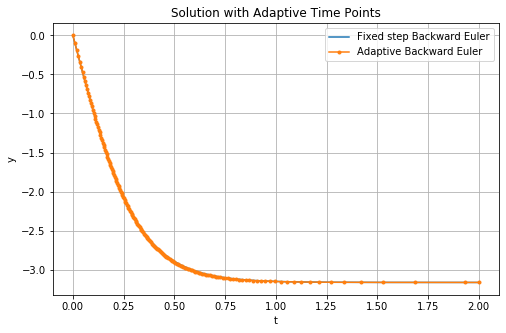

In [83]:
plt.figure(figsize=(8, 5))
plt.plot(t_fixed, y_fixed, label="Fixed step Backward Euler")
plt.plot(t_adapt, y_adapt, "o-", markersize=3, label="Adaptive Backward Euler")
plt.xlabel("t")
plt.ylabel("y")
plt.title("Solution with Adaptive Time Points")
plt.legend()
plt.grid(True)
plt.show()

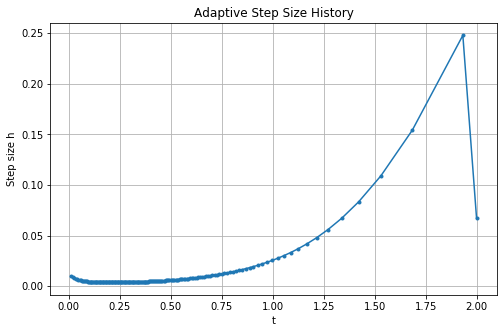

In [73]:
plt.figure(figsize=(8, 5))
plt.plot(t_adapt[1:], h_history, "o-", markersize=3)
plt.xlabel("t")
plt.ylabel("Step size h")
plt.title("Adaptive Step Size History")
plt.grid(True)
plt.show()

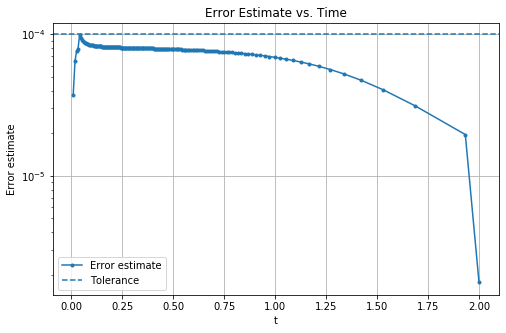

In [74]:
plt.figure(figsize=(8, 5))
plt.semilogy(t_adapt[1:], error_history, "o-", markersize=3, label="Error estimate")
plt.axhline(tol, linestyle="--", label="Tolerance")
plt.xlabel("t")
plt.ylabel("Error estimate")
plt.title("Error Estimate vs. Time")
plt.legend()
plt.grid(True)
plt.show()

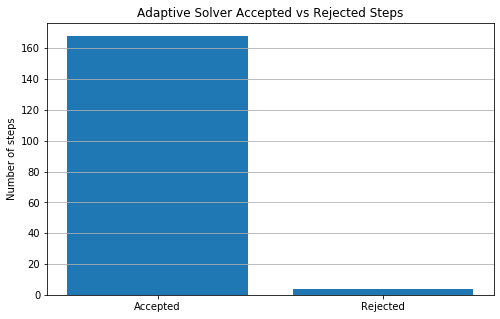

In [77]:
plt.figure(figsize=(8, 5))
plt.bar(
    ["Accepted", "Rejected"],
    [stats_adapt["accepted_steps"], stats_adapt["rejected_steps"]]
)
plt.ylabel("Number of steps")
plt.title("Adaptive Solver Accepted vs Rejected Steps")
plt.grid(True, axis="y")
plt.show()

In [78]:
import pandas as pd

comparison_table = pd.DataFrame({
    "Method": ["Fixed", "Adaptive"],
    "Steps": [stats_fixed["steps"], stats_adapt["accepted_steps"]],
    "Rejected": [0, stats_adapt["rejected_steps"]],
    "Newton Iterations": [stats_fixed["newton_iterations"], stats_adapt["newton_iterations"]],
    "Function Evals": [stats_fixed["function_evals"], stats_adapt["function_evals"]],
})

comparison_table

,Method,Steps,Rejected,Newton Iterations,Function Evals
0,Fixed,200,0,534,534
1,Adaptive,168,4,1549,1549



The fixed-step method uses the same step size for the whole time interval. This is simple, but it can waste work when the solution is smooth. It also may not be accurate enough in regions where the solution changes quickly.

The adaptive method changes the step size based on the error estimate. When the error is small, the solver increases \(h\). When the error is too large, it rejects the step and tries again with a smaller \(h\).

In my results, the adaptive method used the tolerance to control the error instead of blindly using the same step size everywhere. Even though each adaptive step costs more because it computes one full step and two half steps, it can still be more efficient overall because it avoids taking tiny steps everywhere.

The most important comparison is not just step count. We also need to compare Newton iterations and function evaluations because those represent the real computational cost. Even though adaptive stepping required more Newton iterations (1549 vs 534), it achieved similar accuracy with fewer steps (168 vs 200), showing the tradeoff between per-step cost and overall efficiency.

---

## Section 5: Robustness Testing



In [79]:
# Test with a very large initial step size
t_big, y_big, h_big, err_big, flags_big, stats_big = adaptive_implicit_euler(
    y0=0.0,
    t0=0.0,
    t_final=2.0,
    h0=1.0,
    tol=1e-4,
    h_min=1e-6,
    h_max=1.0
)


Large initial h stats:
{'accepted_steps': 168, 'rejected_steps': 6, 'newton_iterations': 1582, 'function_evals': 1582, 'damping_used_count': 1, 'backtracking_steps': 3}
Final y: -3.162223399409041


In [80]:
# Test with very tight tolerance
t_tight, y_tight, h_tight, err_tight, flags_tight, stats_tight = adaptive_implicit_euler(
    y0=0.0,
    t0=0.0,
    t_final=2.0,
    h0=0.05,
    tol=1e-8,
    h_min=1e-8,
    h_max=0.25
)


Tight tolerance stats:
{'accepted_steps': 16687, 'rejected_steps': 6, 'newton_iterations': 100318, 'function_evals': 100318, 'damping_used_count': 0, 'backtracking_steps': 0}
Final y: -3.1622569512864223


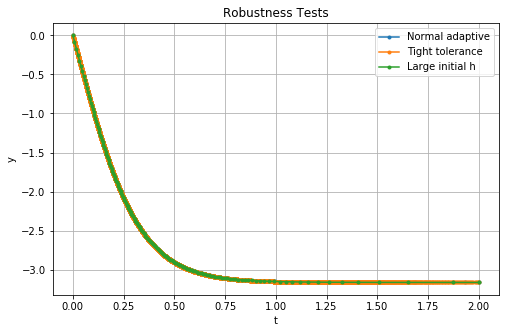

In [81]:
plt.figure(figsize=(8, 5))
plt.plot(t_adapt, y_adapt, "o-", markersize=3, label="Normal adaptive")
plt.plot(t_tight, y_tight, "o-", markersize=3, label="Tight tolerance")
plt.plot(t_big, y_big, "o-", markersize=3, label="Large initial h")
plt.xlabel("t")
plt.ylabel("y")
plt.title("Robustness Tests")
plt.legend()
plt.grid(True)
plt.show()

I tested the solver with a very tight tolerance and with a very large initial step size.

For the tight tolerance case, the solver had to take smaller steps because the error requirement was stricter. This increased the number of accepted steps and Newton iterations.

For the large initial step size case, the solver did not just fail immediately. Instead, it rejected steps and reduced \(h\) until the error was acceptable. This shows why adaptive step size control is useful: the user does not have to guess the perfect step size at the beginning.

Overall, the solver handled both difficult cases without crashing, which shows that damping and adaptive step size control made the method more robust. This demonstrates that the adaptive solver can automatically adjust to difficult situations without manual tuning, which is a major advantage over fixed step size methods.

---

## Bonus 3: Work-Precision Diagram




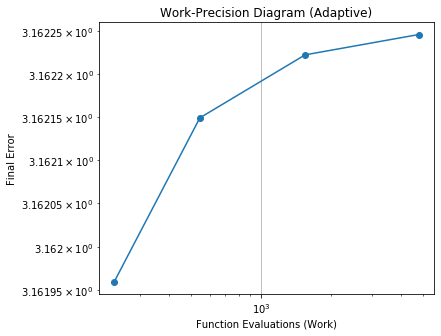

In [84]:
tols = [1e-2, 1e-3, 1e-4, 1e-5]

work = []
error = []

for tol in tols:
    t, y, h_hist, err_hist, flags, stats = adaptive_implicit_euler(
        y0=0.0, t0=0.0, t_final=2.0, h0=0.05, tol=tol
    )

    work.append(stats["function_evals"])
    error.append(abs(y[-1]))  # proxy error
    
    
    
plt.figure(figsize=(6,5))
plt.loglog(work, error, "o-")
plt.xlabel("Function Evaluations (Work)")
plt.ylabel("Final Error")
plt.title("Work-Precision Diagram (Adaptive)")
plt.grid(True)
plt.show()


This plot shows how increasing computational work reduces the final error, demonstrating the efficiency of the adaptive solver.

--- 

## Section 6: Conclusion

In this part, I improved my Part 2 Backward Euler solver by adding damped Newton-Raphson and adaptive step size control.

Damping is necessary when the Newton-Raphson update is too aggressive. If the full Newton step increases the residual or causes instability, the damping factor $\alpha$ reduces the step size and helps the method converge instead of diverging. This is especially important for large step sizes or highly nonlinear problems.

Adaptive step size control is worth the added complexity because a fixed step size is not efficient for all regions of the solution. When the solution changes rapidly, the solver reduces the step size to maintain accuracy. When the solution is smooth, it increases the step size to avoid unnecessary computation. This allows the solver to automatically balance accuracy and efficiency.

The main tradeoff is that adaptive stepping costs more per attempted step due to step-doubling. However, it provides much better control over error and avoids wasting computation. Overall, these improvements made the solver more stable, more automatic, and more reliable than the basic fixed-step method from Part 2.

Key lessons learned:

- Backward Euler is stable for stiff problems, but solving it is harder.
- Newton-Raphson can fail, so damping helps a lot.
- Fixed step size is not ideal, so adaptive step size is way more efficient.
- Step-doubling is a simple way to estimate error.
- Combining everything makes the solver more robust and automatic.